# El asistente clínico GeSIDA: construcción del grafo y recuperación multisalto

Cuaderno didáctico del sistema de producción (asistente sobre las guías de VIH de GeSIDA),
que muestra **sobre artefactos reales** las dos fases:

1. **Indexación** — cómo se construye el grafo de conocimiento clínico desde 8 guías:
   troceado, extracción de **aserciones reificadas** con deóntica y vigencia, capa de
   **entidades ancladas a SNOMED CT** (identidad canónica, sinonimia verificada y jerarquía
   IS_A) y nodos de **Recomendación**.
2. **Recuperación multisalto** — cómo una pregunta clínica *multi-guía* (nivel 4) se
   resuelve operación por operación, con la evidencia cruzando varias guías.

Es el sistema del que se generalizó el trabajo de benchmarks: aquí SNOMED hace de *memoria
canónica de entidades*, las aserciones llevan además grado de evidencia y vigencia, y las
preguntas **nivel 4** (multi-guía) son el análogo clínico del multisalto de 2Wiki.

> Ejecutar con el **kernel del venv** del proyecto (`faiss`, `networkx`, `matplotlib`).
> La recuperación hace unas pocas llamadas a la API de OpenAI (~0,01 \$). **Datos
> públicos** (guías GeSIDA); el sistema de producción no se modifica (solo se lee).

In [1]:
import json, sys, textwrap
import numpy as np, networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
sys.path.insert(0,'../src')
A='../artifacts'
chunks={json.loads(l)['chunk_id']:json.loads(l) for l in open(f'{A}/chunks.jsonl')}
triplets=[json.loads(l) for l in open(f'{A}/triplets.jsonl')]
print(f'corpus: {len(chunks):,} fragmentos (chunks) de las guías GeSIDA')
guias=Counter(c.split('::')[0] for c in chunks)
print('guías y nº de fragmentos:')
for gu,n in guias.most_common(): print(f'   {n:4d}  {gu}')

corpus: 2,694 fragmentos (chunks) de las guías GeSIDA
guías y nº de fragmentos:
    604  PREVENTIVA_VACUNAS
    482  TAR_ADULTOS_2022
    358  EMBARAZO
    347  NEUROCOGNITIVO_2013
    303  PEP
    213  RIESGO_CV_METAB
    200  TB_VIH
    187  ADHERENCIA_2020


## Parte 1 · Construcción del grafo (indexación)

El proceso de indexación —ejecutado una vez, sin ver ninguna pregunta— tiene cuatro etapas:
troceado normativo → extracción de aserciones reificadas → anclaje terminológico a SNOMED →
materialización del grafo. Recorremos cada una con datos reales.

### 1.1 · Troceado normativo

Cada guía se trocea respetando su estructura (secciones, recomendaciones). El `chunk_id`
codifica guía, página y posición.

In [2]:
cid=next(c for c in chunks if c.startswith('EMBARAZO'))
c=chunks[cid]
print('chunk_id :', cid)
print('guía     :', c.get('guia', cid.split('::')[0]))
print('sección  :', c.get('seccion','')[:70])
print('texto    :', textwrap.fill(c.get('texto','')[:320], 96))

chunk_id : EMBARAZO::p1::0
guía     : EMBARAZO
sección  : (inicio)
texto    : |Col1|Col2|Col3|Col4|Col5|Col6|Col7|Col8|Col9|Col10| |---|---|---|---|---|---|---|---|---|---|
||||||||||| ||||||||||| ||||||||||| ||||||||||| |**DOCUMENTO DE CONSENSO PARA**<br>**EL
SEGUIMIENTO DE LA INFECCIÓN**<br>**POR EL VIH EN RELACION CON LA**<br>**REPRODUCCIÓN, EMBARAZO,
PARTO**<br>**Y PROFILAXIS DE LA TRANSMISI


### 1.2 · Extracción de aserciones reificadas *clínicas*

De cada fragmento se extraen **aserciones**: hechos clínicos promovidos a objeto con roles
tipados (intervención, población diana, resultado esperado), **polaridad** (`is_negated`),
**grado de evidencia** y tipo de aserción. Es la misma reificación que en los benchmarks,
enriquecida con los atributos que la clínica exige.

In [3]:
asers=[a for d in triplets for a in d.get('aserciones',[]) if isinstance(a,dict)]
print(f'total aserciones extraídas: {len(asers):,}')
print('tipos de aserción:', dict(Counter(a.get('tipo_asercion') for a in asers)))
print('\n--- ejemplo de aserción terapéutica (roles n-arios + metadatos clínicos):')
a=next(a for a in asers if a.get('tipo_asercion')=='RecomendacionTerapeutica' and a.get('poblacion_diana'))
for k in ('id_asercion','intervencion','poblacion_diana','resultado_esperado','relacion_base','is_negated','evidence_level'):
    print(f'   {k:20}: {a.get(k)}')
print('   frase τ            :', textwrap.fill(a.get('descripcion_relacion',''),90))

total aserciones extraídas: 8,444
tipos de aserción: {'RecomendacionTerapeutica': 4219, 'Diagnostico': 265, 'EvidenciaClinica': 2838, 'Advertencia': 1122}

--- ejemplo de aserción terapéutica (roles n-arios + metadatos clínicos):
   id_asercion         : TAR_ADULTOS_2022::p1::0_1
   intervencion        : Tratamiento antirretroviral
   poblacion_diana     : Adultos con VIH/SIDA
   resultado_esperado  : Control de la infección por VIH y prevención de inmunodeficiencia
   relacion_base       : TREATS
   is_negated          : False
   evidence_level      : None
   frase τ            : El tratamiento antirretroviral se recomienda para tratar la infección por VIH en adultos,
con el objetivo de controlar la enfermedad y evitar la progresión a inmunodeficiencia.


### 1.3 · Anclaje terminológico a SNOMED CT (la memoria canónica)

Cada mención de entidad se ancla a un **SCTID** (identificador SNOMED), lo que da identidad
canónica, sinonimia *verificada* (no por umbral de coseno, sino por compartir concepto) y
una jerarquía **IS_A** de subsunción. Es el equivalente clínico, curado, del diccionario de
entidades derivado del corpus en los benchmarks.

In [4]:
ed=json.load(open(f'{A}/entity_dictionary.json'))
anclados=[(k,v) for k,v in ed.items() if v.get('codigo_umls') or v.get('relaciones_umls')]
print(f'entidades en el diccionario: {len(ed):,}')
print('tipos de entidad:', dict(Counter(v.get('tipo_entidad') for v in ed.values())))
print('\n--- ejemplos de entidad con su tipo:')
for k in ('Dolutegravir','Rifampicina','Embarazo'):
    if k in ed: print(f'   {k:14} -> tipo={ed[k].get("tipo_entidad")}  alias={ed[k].get("alias")[:3]}')

entidades en el diccionario: 7,737
tipos de entidad: {'Enfermedad': 764, 'CondicionClinica': 2144, 'Intervencion': 1946, 'Poblacion': 802, 'ResultadoClinico': 854, 'Farmaco': 1226, 'Laboratorio': 1}

--- ejemplos de entidad con su tipo:
   Dolutegravir   -> tipo=Farmaco  alias=[]
   Rifampicina    -> tipo=Farmaco  alias=[]
   Embarazo       -> tipo=CondicionClinica  alias=[]


### 1.4 · El grafo de conocimiento: nodos y aristas

Se materializa un grafo con cinco tipos de nodo (Chunk, Entidad, Asercion, Recomendacion,
Concepto SNOMED) y aristas tipadas: roles de la aserción (`HAS_INTERVENTION`,
`TARGET_POPULATION`, `HAS_OUTCOME`), procedencia (`EXTRAIDO_DE`), mención (`MENCIONADO_EN`),
capa SNOMED (`ANCLADA_A`, `IS_A`, `SINONIMO_DE`) y normativa (`CONTIENE_RECOMENDACION`).

In [5]:
g=nx.read_graphml(f'{A}/knowledge_graph.graphml')
print(f'GRAFO CLÍNICO: {g.number_of_nodes():,} nodos | {g.number_of_edges():,} aristas')
import pandas as pd
tn=Counter(d.get('tipo') for _,d in g.nodes(data=True))
te=Counter(d.get('tipo_relacion') for _,_,d in g.edges(data=True))
print('\nnodos por tipo:'); [print(f'   {n:14} {c:6,}') for n,c in tn.most_common()]
print('aristas por tipo:'); [print(f'   {n:22} {c:6,}') for n,c in te.most_common()]

GRAFO CLÍNICO: 22,807 nodos | 51,071 aristas

nodos por tipo:
   Asercion        8,444
   Entidad         7,737
   Concepto        2,875
   Chunk           2,419
   Recomendacion   1,332
aristas por tipo:
   EXTRAIDO_DE             8,444
   MENCIONADA_EN_REC       8,253
   MENCIONADO_EN           6,626
   CONTIENE_MENCION        6,626
   HAS_INTERVENTION        5,780
   SINONIMO_DE             5,380
   IS_A                    2,649
   TARGET_POPULATION       2,610
   ANCLADA_A               2,326
   CONTIENE_RECOMENDACION  1,332
   HAS_OUTCOME             1,045


[None, None, None, None, None, None, None, None, None, None, None]

### 1.5 · Un subgrafo real alrededor de *dolutegravir*

Dibujamos el vecindario del concepto dolutegravir: la entidad, sus aserciones (hechos), los
fragmentos de origen, el concepto SNOMED al que se ancla y sus sinónimos. Es la unidad
estructural que el paseo aleatorio recorrerá en consulta.

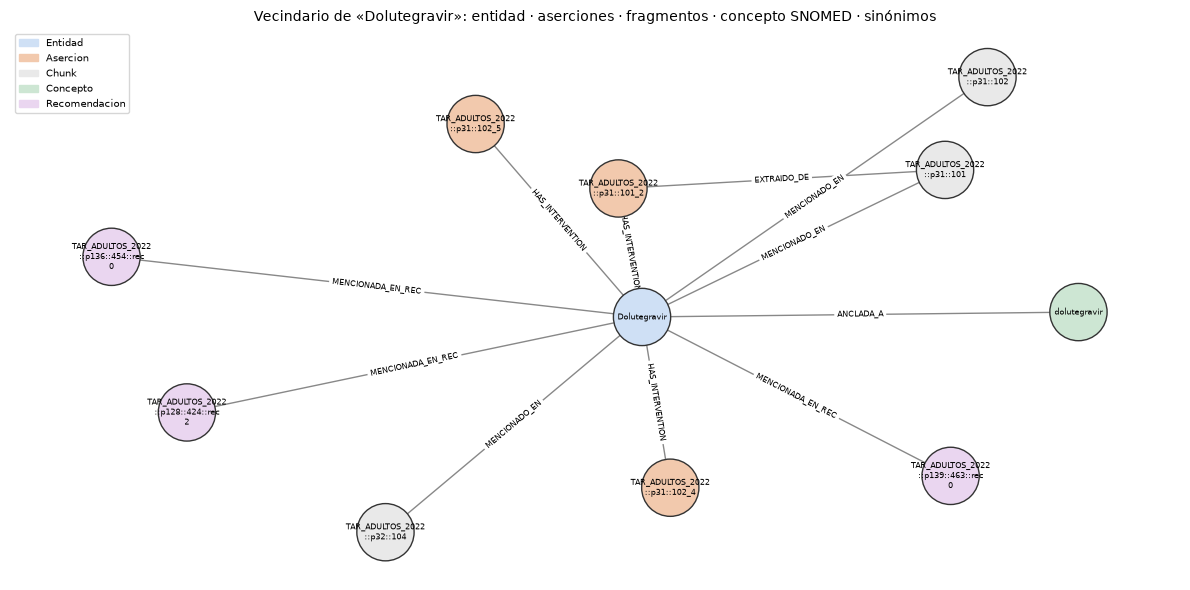

In [6]:
import matplotlib.patches as mpatches
ent='Dolutegravir'
sub=nx.DiGraph(); COL={'Entidad':'#cfe0f5','Asercion':'#f2c9ad','Chunk':'#e9e9e9','Concepto':'#cde6d3','Recomendacion':'#ead6f0'}
def tipo(n): return g.nodes[n].get('tipo','?')
vecinos=[]
if g.has_node(ent):
    for _,v,d in list(g.out_edges(ent,data=True))[:40]: vecinos.append((ent,v,d.get('tipo_relacion')))
    for u,_,d in list(g.in_edges(ent,data=True))[:40]: vecinos.append((u,ent,d.get('tipo_relacion')))
# quedarnos con una muestra legible: hasta 3 aserciones, 2 conceptos, 2 sinonimos, 2 chunks
sel=[]; cuenta=Counter()
for u,v,rel in vecinos:
    otro=v if u==ent else u; t=tipo(otro)
    if cuenta[t]<3: sel.append((u,v,rel)); cuenta[t]+=1
for u,v,rel in sel: sub.add_edge(u,v,rel=rel)
# ademas: de una asercion, mostrar su chunk
for n in list(sub.nodes()):
    if tipo(n)=='Asercion':
        for _,v,d in g.out_edges(n,data=True):
            if tipo(v)=='Chunk': sub.add_edge(n,v,rel=d.get('tipo_relacion')); break
        break
plt.figure(figsize=(12,6))
pos=nx.spring_layout(sub,seed=3,k=1.1)
nx.draw_networkx_nodes(sub,pos,node_size=1700,edgecolors='#333',
    node_color=[COL.get(tipo(n),'#fff') for n in sub])
nx.draw_networkx_labels(sub,pos,font_size=6,
    labels={n:textwrap.fill(str(g.nodes[n].get('nombre',n))[:34],16) for n in sub})
nx.draw_networkx_edges(sub,pos,edge_color='#888',arrowsize=8)
nx.draw_networkx_edge_labels(sub,pos,edge_labels=nx.get_edge_attributes(sub,'rel'),font_size=5.5)
plt.legend(handles=[mpatches.Patch(color=v,label=k) for k,v in COL.items()],
           loc='upper left',fontsize=7)
plt.title('Vecindario de «Dolutegravir»: entidad · aserciones · fragmentos · concepto SNOMED · sinónimos',fontsize=10)
plt.axis('off'); plt.tight_layout(); plt.show()

## Parte 2 · Recuperación multisalto sobre una pregunta clínica

Cargamos el recuperador de producción (`CatRAGRetriever`) y trazamos una pregunta **nivel 4
multi-guía**, que exige integrar evidencia de varias guías —el análogo clínico del
multisalto.

In [7]:
from asistente_vih.retrieval.catrag_retriever import CatRAGRetriever
from openai import OpenAI
r=CatRAGRetriever(OpenAI())
# una pregunta nivel 4 real del banco
banco=[json.loads(l) for l in open(f'{A}/eval_dataset.jsonl')]
def meta(d): return eval(d['metadata']) if isinstance(d['metadata'],str) else d['metadata']
def inp(d):  return eval(d['inputs'])   if isinstance(d['inputs'],str)   else d['inputs']
nivel4=[d for d in banco if meta(d).get('nivel')==4]
PREG="Gestante con tuberculosis en tratamiento con rifampicina: ¿cómo se ajusta la dosis de dolutegravir y qué se recomienda para el parto?"
print('PREGUNTA (multi-guía):', PREG)
print(f'(el banco tiene {len(nivel4)} preguntas nivel 4 multi-guía)')

Cargando motor CatRAG...


PPR dinamico: 8444 aserciones con embedding.
CatRAG listo: 7737 entidades indexadas, Grafo con 22807 nodos.
PREGUNTA (multi-guía): Gestante con tuberculosis en tratamiento con rifampicina: ¿cómo se ajusta la dosis de dolutegravir y qué se recomienda para el parto?
(el banco tiene 73 preguntas nivel 4 multi-guía)


### Operación 1 · Extracción y expansión de entidades de la pregunta (LLM)

El recuperador extrae los conceptos clínicos clave y genera sinónimos/variantes — el primer
paso del anclaje.

In [8]:
ents=r._extract_query_entities(PREG)
print('entidades/variantes extraídas de la pregunta:'); print('   ', ents)

entidades/variantes extraídas de la pregunta:
    ['Gestante', 'Embarazada', 'Mujer en estado de gestación', 'Tuberculosis', 'TBC', 'Infección tuberculosa', 'Rifampicina', 'Rifampin', 'Antibiótico', 'Dolutegravir', 'Antirretroviral', 'Tratamiento antirretroviral', 'Parto', 'Nacimiento', 'Delivery.']


### Operación 2 · Anclaje simbólico multi-semilla (FAISS sobre entidades)

Cada entidad y sus variantes se buscan en el índice FAISS de entidades del grafo: son las
**anclas** que fijan el paseo a los nodos exactos de la pregunta (dolutegravir, rifampicina,
gestación…).

In [9]:
anclas=r._symbolic_anchoring(ents, top_k=2)
anclas=[a for a in anclas if r.search_graph.has_node(a)]
print('anclas (nodos-entidad del grafo):'); print('   ', anclas)

anclas (nodos-entidad del grafo):
    ['Antirretroviral', 'Mujer Gestante', 'Rifampin', 'Rifampicina', 'Embarazadas', 'Tb', 'Embarazada', 'Tbc Pulmonar', 'Antibióticos', 'Gestante', 'Tratamiento Antirretroviral', 'Resultados Del Nacimiento', 'Birth', 'Tuberculosis', 'Rifampicin', 'Mujeres Gestantes', 'Dolutegravir/Lamivudine', 'M Tuberculosis', 'Antiretroviral', 'Infección Tuberculosa', 'Dolutegravir', 'Dispensación', 'Infección Tuberculosa Latente', 'Parto A Término', 'Parto', 'Tratamiento Antirretroviral Combinado', 'Gestantes', 'Cart', 'Profilaxis Antibiótica']


### Operación 3 · Semillas conceptuales por SNOMED (subsunción)

Las entidades ancladas activan su **concepto SNOMED y sus ancestros** (jerarquía IS_A) con
peso decreciente por distancia. Esto permite que la pregunta alcance recomendaciones
formuladas sobre un concepto *más general* que el término exacto — un salto que la sinonimia
superficial no da.

In [10]:
conc=r._semillas_conceptuales(ents)
print('semillas conceptuales SNOMED (concepto -> peso por subsunción):')
for n,w in sorted(conc.items(),key=lambda x:-x[1])[:8]:
    nom=r.graph.nodes[n].get('nombre',n) if r.graph.has_node(n) else n
    print(f'   {w:.3f}  {n}  ({nom})')
if not conc: print('   (linker SNOMED no disponible en este entorno; el resto del pipeline no depende de él)')

semillas conceptuales SNOMED (concepto -> peso por subsunción):
   1.000  sct:77386006  (embarazo confirmado)
   1.000  sct:56717001  (tuberculosis)
   1.000  sct:387159009  (rifampicina)
   1.000  sct:713464000  (dolutegravir)
   0.500  sct:118185001  (hallazgo relacionado con el embarazo)
   0.500  sct:88415009  (micobacteriosis)
   0.500  sct:2537003  (agente antituberculoso)
   0.500  sct:427965001  (inhibidor de transferencia de cadenas de integrasa)


### Operación 4 · Siembra query-to-fact y densa

Se combinan: las entidades de las **aserciones más afines** a la pregunta (query-to-fact con
anti-concentrador), los **pasajes** con score denso (fusión con recuperación densa), las
anclas (peso ε) y las semillas conceptuales. Es el vector de personalización del paseo.

In [11]:
qv=r._embed_query(PREG)
hechos=r._semillas_por_hechos(qv)
print('semillas por hechos (entidad -> peso), top-6:')
for n,w in sorted(hechos.items(),key=lambda x:-x[1])[:6]:
    nom=r.graph.nodes[n].get('nombre',n) if r.graph.has_node(n) else n
    print(f'   {w:.3f}  {nom}')

semillas por hechos (entidad -> peso), top-6:
   0.978  Mujer Que Queda Gestante Tomando Tar Y Está Bien Controlada
   0.494  Sujetos Sanos
   0.474  Resultados Del Nacimiento
   0.240  Mujeres Gestantes
   0.163  Drv/R


### Operación 5 · Paseo aleatorio modulado y resultado multi-guía

El PPR corre sobre el grafo con las transiciones a las aserciones moduladas por la consulta
y el sesgo por intención (población/numérica). El resultado son fragmentos ordenados que
**cruzan varias guías** — la cadena de evidencia multi-guía.

In [12]:
hits=r.search(PREG, k=8, modo='grafo')
print('top-8 fragmentos recuperados (guía · sección):')
vistas=set()
for h in hits:
    gu=getattr(h,'guia','?'); vistas.add(gu)
    print(f'   [{gu:20}] {getattr(h,"seccion","")[:46]:46}  score={getattr(h,"score",0):.4f}')
print('\nguías distintas cubiertas por la recuperación:', sorted(vistas))
print('-> la evidencia cruza varias guías: es multisalto clínico (multi-guía).')

top-8 fragmentos recuperados (guía · sección):
   [NEUROCOGNITIVO_2013 ] 60                                              score=0.0124
   [EMBARAZO            ] 7. El cumplimiento del TAR debe ser una priori  score=0.0062
   [TB_VIH              ] 5.1 Concepto                                    score=0.0052
   [EMBARAZO            ] 61 la reproducción, embarazo, parto y profilax  score=0.0036
   [TAR_ADULTOS_2022    ] Bibliografía                                    score=0.0026
   [EMBARAZO            ] 61 la reproducción, embarazo, parto y profilax  score=0.0025
   [TB_VIH              ] 2.1. ¿CUÁNTOS Y QUÉ FÁRMACOS USAR?              score=0.0022
   [TB_VIH              ] 3.2. ¿QUÉ RÉGIMEN DE TAR USAR?                  score=0.0021

guías distintas cubiertas por la recuperación: ['EMBARAZO', 'NEUROCOGNITIVO_2013', 'TAR_ADULTOS_2022', 'TB_VIH']
-> la evidencia cruza varias guías: es multisalto clínico (multi-guía).


### La traza de razonamiento (procedencia auditable)

Cada fragmento recuperado trae su **traza** desde las semillas: el camino
entidad → aserción → fragmento que lo justifica. Es lo que permite la trazabilidad clínica
(y, en producción, la verificación de deóntica y vigencia).

In [13]:
for h in hits[:3]:
    tr=getattr(h,'reasoning_trace',[])
    print(f'[{getattr(h,"guia","?")}] {getattr(h,"seccion","")[:40]}')
    for paso in (tr[:3] if tr else ['(sin traza)']): print('     ·', paso)

[NEUROCOGNITIVO_2013] 60
     · Semilla [Cart] ➔ Mención directa ➔ NEUROCOGNITIVO_2013::p61::202
     · Semilla [Cart] ➔ Aserción [REDUCES_RISK] ➔ NEUROCOGNITIVO_2013::p61::202
[EMBARAZO] 7. El cumplimiento del TAR debe ser una 
     · (sin traza)
[TB_VIH] 5.1 Concepto
     · Semilla [Tb] ➔ Aserción [CAUSES] ➔ TB_VIH::p7::19
     · Semilla [Tb] ➔ Mención directa ➔ TB_VIH::p7::19


## Parte 3 · Síntesis: el paralelo con los benchmarks

| pieza | benchmark (2Wiki/HotpotQA) | clínica (GeSIDA) |
|---|---|---|
| memoria canónica de entidades | diccionario derivado del corpus | **SNOMED CT** (SCTID), curado y auditable |
| aserción reificada | frase τ + roles n-arios | + **deóntica**, grado de evidencia y **vigencia** |
| subsunción / puentes | jerarquía Wikidata (potencial) | **IS_A de SNOMED** (activa en producción) |
| multisalto | pregunta bridge (2–4 pasajes) | pregunta **nivel 4 multi-guía** |
| pasaje propio | artículo de la entidad | sección normativa de la guía |
| salvaguarda | — | **abstención + verificación** de deóntica/vigencia |

**Lectura.** El asistente clínico es el origen del que se generalizó el sistema evaluado en
benchmarks públicos: las mismas piezas (reificación, memoria canónica de entidades,
recuperación multisalto por grafo) con terminología curada (SNOMED en el papel del
diccionario), metadatos clínicos (deóntica, vigencia) y salvaguardas de seguridad. La
recuperación multi-guía que acabamos de trazar es el análogo clínico de la cadena puente de
2Wiki. Detalle del método y su evaluación: `docs/presentacion_sistema.pdf`,
`docs/paper_draft_en.pdf`, `artifacts/wiki2/INFORME.md`.